In [95]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
gen_data= pd.read_csv("/content/Plant_1_Generation_Data.csv")
weather_data= pd.read_csv("/content/Plant_1_Weather_Sensor_Data.csv")

In [3]:
gen_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
gen_data.shape

(68778, 7)

In [5]:
gen_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [9]:
gen_data

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,0.0,0.0,0.000,6259559.0
1,0.0,0.0,0.000,6183645.0
2,0.0,0.0,0.000,6987759.0
3,0.0,0.0,0.000,7602960.0
4,0.0,0.0,0.000,7158964.0
...,...,...,...,...
68773,0.0,0.0,5967.000,7287002.0
68774,0.0,0.0,5147.625,7028601.0
68775,0.0,0.0,5819.000,7251204.0
68776,0.0,0.0,5817.000,6583369.0


In [17]:
weather_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [18]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB


In [43]:
weather_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [47]:
gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'])
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'])

/tmp/ipykernel_1749/3320768613.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'])


In [48]:
gen_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [49]:
final_dataset = pd.merge(gen_data, weather_data, on='DATE_TIME')

In [195]:
final_dataset.shape


(68774, 9)

In [196]:
final_dataset.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Hour,Day,Month,Day_of_Week
0,2020-05-15,0.0,25.184316,22.857507,0.0,0,15,5,4
1,2020-05-15,0.0,25.184316,22.857507,0.0,0,15,5,4
2,2020-05-15,0.0,25.184316,22.857507,0.0,0,15,5,4
3,2020-05-15,0.0,25.184316,22.857507,0.0,0,15,5,4
4,2020-05-15,0.0,25.184316,22.857507,0.0,0,15,5,4


In [197]:
final_dataset.drop(['PLANT_ID_x','SOURCE_KEY_x'],axis=1,inplace=True)

KeyError: "['PLANT_ID_x', 'SOURCE_KEY_x'] not found in axis"

In [210]:
final_dataset.drop(['DC_POWER','DATE_TIME'],axis=1,inplace=True)

In [211]:
final_dataset.drop(['DAILY_YIELD','TOTAL_YIELD'],axis=1,inplace=True)

KeyError: "['DAILY_YIELD', 'TOTAL_YIELD'] not found in axis"

In [212]:
final_dataset.isna().sum()

,0
AC_POWER,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0
Hour,0
Day,0
Month,0
Day_of_Week,0


In [213]:
CORR=final_dataset.corr(numeric_only=True)


In [214]:
corr = final_dataset.select_dtypes(include="number").corr()["AC_POWER"].sort_values(
    ascending=False
)

print(corr)

AC_POWER               1.000000
IRRADIATION            0.989340
MODULE_TEMPERATURE     0.954924
AMBIENT_TEMPERATURE    0.724903
Day                    0.032997
Hour                   0.024080
Day_of_Week            0.017671
Month                 -0.037525
Name: AC_POWER, dtype: float64


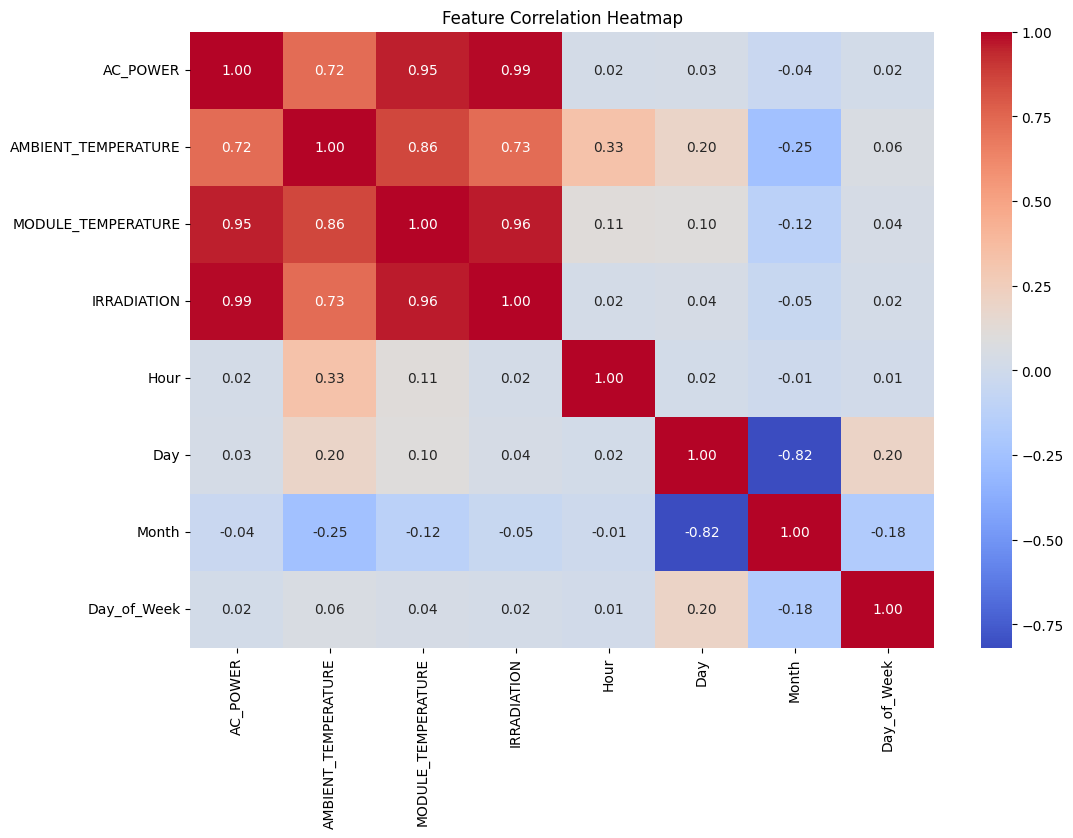

In [203]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    final_dataset.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [216]:
final_dataset.drop(['Day','Month','Hour','Day_of_Week'],inplace=True,axis=1)

In [217]:
from sklearn.preprocessing import StandardScaler

In [218]:
scaler=StandardScaler(copy=True, with_mean=True, with_std=True)

In [219]:
X=final_dataset.drop(['AC_POWER'],axis=1)
Y = final_dataset['AC_POWER']

In [220]:
from sklearn.feature_selection import SelectKBest, f_regression


selector = SelectKBest(
    score_func=f_regression,
    k="all"
)

X_selected = selector.fit_transform(X, Y)

In [221]:
scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores = scores.sort_values(
    by="Score",
    ascending=False
)

print(scores)

               Feature         Score
2          IRRADIATION  3.174236e+06
1   MODULE_TEMPERATURE  7.116682e+05
0  AMBIENT_TEMPERATURE  7.615873e+04


In [222]:
selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'], dtype='object')


In [223]:
from sklearn.model_selection import train_test_split

In [224]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [225]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(55019, 3)
(13755, 3)
(55019,)
(13755,)


In [226]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [227]:
print(X_train)

[[-0.62884596 -0.71875788 -0.7693962 ]
 [-0.63909586 -0.72809322 -0.7693962 ]
 [ 0.67208784  0.7692599   0.59590148]
 ...
 [-0.33720977  0.16149992  0.17834117]
 [ 0.91237942  1.72672653  1.44881401]
 [ 0.07378988  1.00010391  1.18035557]]


In [228]:
from sklearn.linear_model import LinearRegression


In [229]:
lr=LinearRegression()

In [230]:
lr.fit(X_train,Y_train)

LinearRegression()

In [231]:
y_pred= lr.predict(X_test)

In [232]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


In [233]:
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 26.30905127625147
MSE : 3081.630731049853
RMSE: 55.512437624822894
R²  : 0.9800288894346422


In [194]:
r2_score(Y_test,y_pred)

0.9800288894346422

In [107]:
mean_squared_error(Y_test,y_pred)

1.9678872312912343

In [110]:
print(X.columns)

Index(['DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID_y',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')


In [234]:
from sklearn.ensemble import RandomForestRegressor


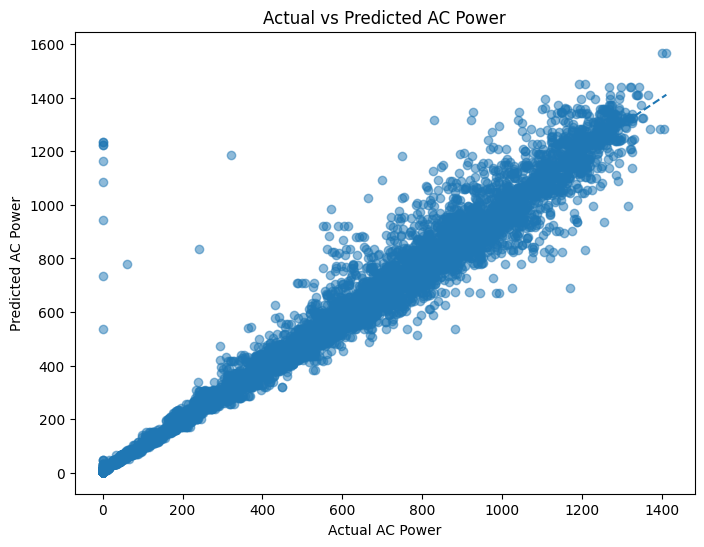

In [238]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(Y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Actual vs Predicted AC Power")

plt.show()

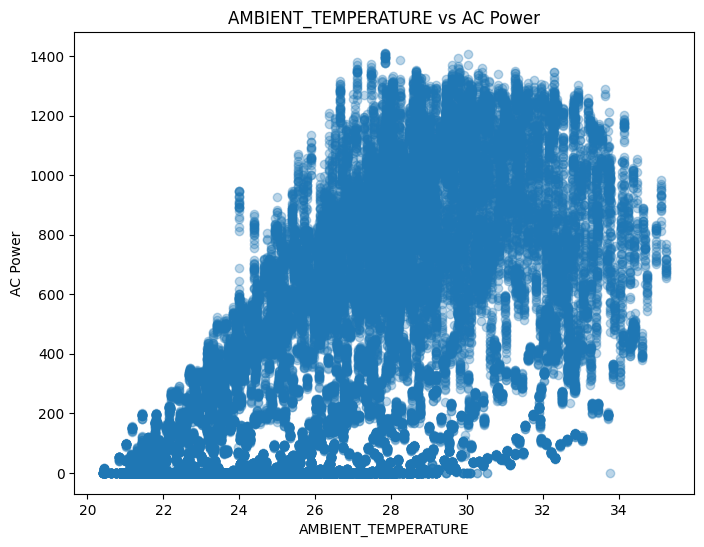

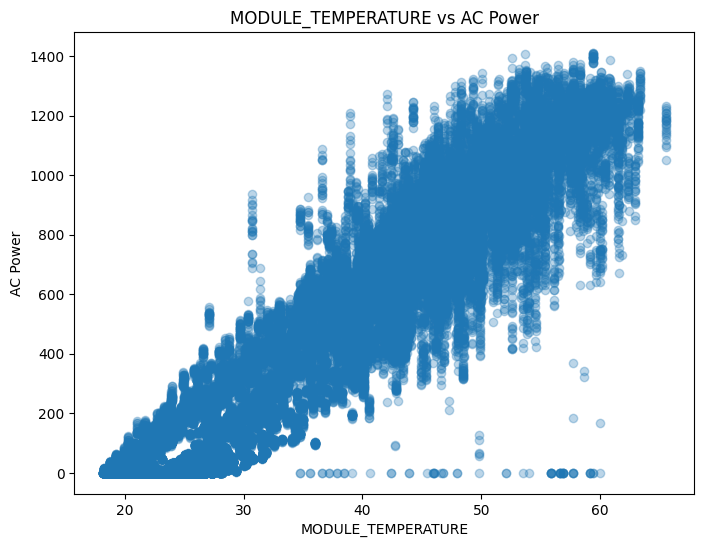

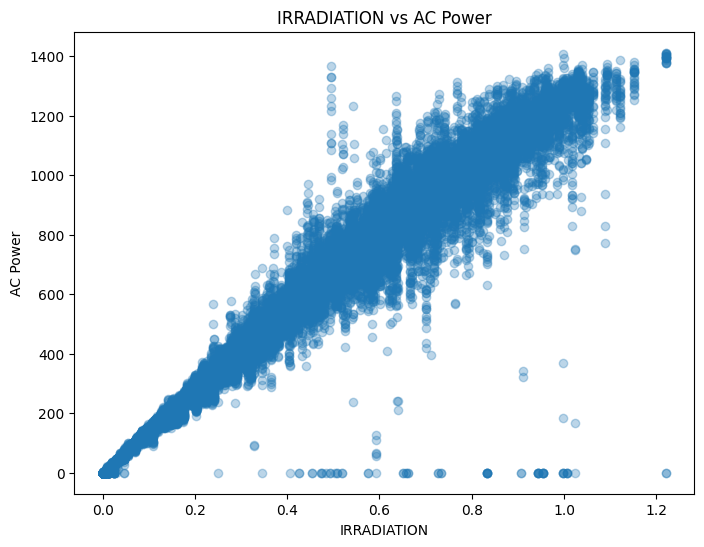

In [240]:
features = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

for feature in features:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        final_dataset[feature],
        final_dataset["AC_POWER"],
        alpha=0.3
    )

    plt.xlabel(feature)
    plt.ylabel("AC Power")
    plt.title(f"{feature} vs AC Power")

    plt.show()